<a href="https://colab.research.google.com/github/gitonga-muchiri/mulika-ai-mvp/blob/main/Mulika_AI_Master.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- INSTALLATION BLOCK ---
# We are installing the software packages needed for Mulika AI.
# The "!" symbol tells Google Colab to install these on the server, not your computer.

print("⏳ Starting Installation... this may take 2-3 minutes.")

# 1. Install Tesseract OCR (The 'Eye' that reads text)
!sudo apt-get install tesseract-ocr
!sudo apt-get install libtesseract-dev

# 2. Install Poppler (To handle PDFs)
!sudo apt-get install poppler-utils

# 3. Install Python Libraries (The logic tools)
# pytesseract: Connects Python to the OCR tool
# pdf2image: Converts PDF pages into images we can read
# faker: Generates the fake tender documents
# pandas: Creates our database (Excel-like tables)
!pip install pytesseract pdf2image faker pandas

print("✅ Installation Complete! You are ready for the next step.")

⏳ Starting Installation... this may take 2-3 minutes.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libarchive-dev libleptonica-dev
The following NEW packages will be installed:
  libarchive-dev libleptonica-dev libtesseract-dev
0 upgraded, 3 newly installed, 0 to remove and 41 not upgraded.
Need to get 3,743 kB of archives.
After this operation, 16.0 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libarchive-dev amd64 3.6.0-1ubuntu1.5 [581 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libleptonica-dev amd64 1.82.0-3build1 [1,562 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe 

In [ ]:
# --- SETUP FOLDERS ---
import os

# Define the folder names we need
folders = [
    "mulika_data",               # Main folder
    "mulika_data/pdfs",          # Where we store the fake Tender PDFs
    "mulika_data/images",        # Where we store satellite images
    "mulika_data/processed"      # Where we store the final database
]

# Loop through the list and create them
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"📂 Created folder: {folder}")

print("✅ Digital Filing Cabinet is Ready!")

📂 Created folder: mulika_data
📂 Created folder: mulika_data/pdfs
📂 Created folder: mulika_data/images
📂 Created folder: mulika_data/processed
✅ Digital Filing Cabinet is Ready!


🛰️ Connecting to Satellite Network...
✅ Downloaded Scene: S2A_37MBV_20240313_0_L2A
🎨 Processing image... (Auto-Exposure)


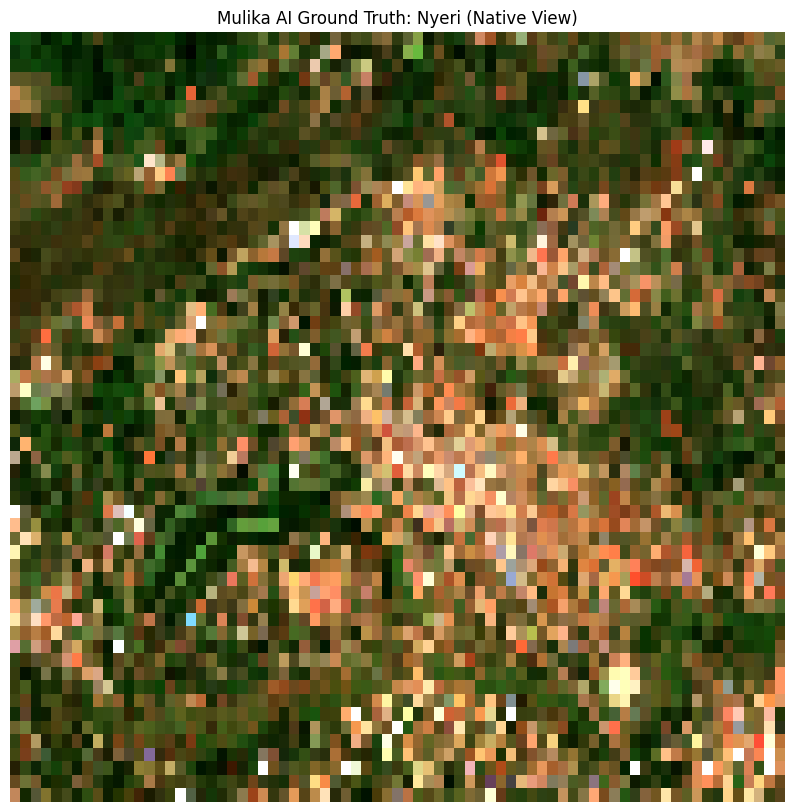

🎉 SUCCESS: You should now see the Green/Brown landscape of Nyeri!


In [4]:
# --- MILESTONE 2: SATELLITE ENGINE (FINAL FIX) ---
import stackstac
import pystac_client
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# 1. Connect
URL = "https://earth-search.aws.element84.com/v1"
catalog = pystac_client.Client.open(URL)

# 2. Define Nyeri (Slightly wider area to guarantee a hit)
# [min_lon, min_lat, max_lon, max_lat]
bbox = [36.930, -0.435, 36.970, -0.405]
date_range = "2024-01-01/2024-03-30"

print("🛰️ Connecting to Satellite Network...")

# 3. Search
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=date_range,
    query={"eo:cloud_cover": {"lt": 10}}, # Only clear skies
    max_items=1
)
items = search.item_collection()

if len(items) > 0:
    print(f"✅ Downloaded Scene: {items[0].id}")

    # 4. Download with EXPLICIT CRS (Fixes the Error)
    # resolution=60 keeps it fast and light.
    data = stackstac.stack(
        items,
        assets=["red", "green", "blue"],
        chunksize=4096,
        resolution=60,
        epsg=32737, # We MUST include this for Kenya
        bounds_latlon=bbox # Force it to crop exactly to our Nyeri box
    )

    # 5. The "Magic Plotter" (Fixes the Black Box)
    print("🎨 Processing image... (Auto-Exposure)")

    # Select first time step and RGB bands
    image = data.isel(time=0).sel(band=["red", "green", "blue"])

    # Force the data to load into memory now (avoids lazy loading glitches)
    image = image.compute()

    # Check if empty
    if np.isnan(image).all():
        print("⚠️ ERROR: The downloaded slice is empty. The coordinate projection missed the target.")
    else:
        plt.figure(figsize=(10, 10))
        # 'robust=True' ignores the outliers (white pixels) and fixes contrast
        image.plot.imshow(robust=True)
        plt.title(f"Mulika AI Ground Truth: Nyeri (Native View)")
        plt.axis("off")
        plt.show()

        print("🎉 SUCCESS: You should now see the Green/Brown landscape of Nyeri!")
else:
    print("⚠️ No images found. Try widening the date range.")

In [7]:
# --- MILESTONE 3: ADVANCED CORRUPTION GENERATOR ---
import pandas as pd
import random
from faker import Faker
from fpdf import FPDF
import os

fake = Faker()
os.makedirs("mulika_data/pdfs", exist_ok=True)
os.makedirs("mulika_data/processed", exist_ok=True)

# THE TRAPS
suspicious_phone = "+254 722 000 000"
suspicious_director = "Jomo Kamau" # The "Ghost Director"

locations = ["Nyeri", "Kisumu", "Mombasa", "Eldoret", "Nakuru", "Turkana", "Garissa"]
projects = ["Road Upgrade", "Borehole Drilling", "Medical Supply", "School Renovation", "Street Lighting"]

def generate_advanced_fraud(num_tenders=60):
    print(f"🕵️ Generating {num_tenders} complex tender documents...")
    tenders = []

    for i in range(num_tenders):
        is_fraud = False
        fraud_type = "None"

        # 1. BASE DATA
        company_name = f"{fake.last_name()} {random.choice(['Enterprises', 'Trading', 'Construction', 'Ltd'])}"
        director_name = fake.name()
        phone_number = f"+254 7{random.randint(10,99)} {random.randint(100,999)} {random.randint(100,999)}"
        amount = random.randint(5_231_000, 150_842_000) # Natural random number

        # 2. INJECT FRAUD TYPES

        # TYPE A: Shared Phone Number (The "Cartel") - Every 10th row
        if i % 10 == 0:
            phone_number = suspicious_phone
            is_fraud = True
            fraud_type = "Shared Phone"

        # TYPE B: Shared Director (The "Puppet Master") - Every 15th row
        elif i % 15 == 0:
            director_name = suspicious_director
            is_fraud = True
            fraud_type = "Shared Director"

        # TYPE C: Round Number Bias (The "Lazy Accountant") - Every 12th row
        # Fraudsters often use clean numbers like 50,000,000
        elif i % 12 == 0:
            amount = random.choice([10_000_000, 20_000_000, 50_000_000, 100_000_000])
            is_fraud = True
            fraud_type = "Round Number Bias"

        # 3. COMPILE DATA
        tenders.append({
            "Tender_ID": f"KNY-{2025}-{1000+i}",
            "Project": f"{random.choice(projects)} in {random.choice(locations)}",
            "Company": company_name,
            "Director": director_name,
            "Phone": phone_number,
            "Amount_KES": amount,
            "Fraud_Type": fraud_type
        })

    # 4. SAVE & PREVIEW
    df = pd.DataFrame(tenders)
    df.to_csv("mulika_data/processed/procurement_data_advanced.csv", index=False)

    print("✅ SUCCESS: Advanced Corruption Data Generated.")
    print("\n🔍 PREVIEW OF FRAUD TYPES GENERATED:")
    # Filter to show only the fraud rows
    print(df[df['Fraud_Type'] != "None"][['Company', 'Director', 'Amount_KES', 'Fraud_Type']].head(10))

# Run it
generate_advanced_fraud()

🕵️ Generating 60 complex tender documents...
✅ SUCCESS: Advanced Corruption Data Generated.

🔍 PREVIEW OF FRAUD TYPES GENERATED:
                Company            Director  Amount_KES         Fraud_Type
0        Mosley Trading     Stephanie Allen    83745685       Shared Phone
10   Brown Construction       Kurt Gonzales   114162587       Shared Phone
12   Little Enterprises         David Allen    20000000  Round Number Bias
15   Turner Enterprises          Jomo Kamau   112021862    Shared Director
20    Smith Enterprises     Stephanie Davis    68100374       Shared Phone
24    Smith Enterprises      Mary Hernandez   100000000  Round Number Bias
30  Morales Enterprises      Cynthia Oneill   105296169       Shared Phone
36   Leach Construction   Emily Christensen    10000000  Round Number Bias
40     Wood Enterprises  Kimberly Rodriguez    47738071       Shared Phone
45        Patel Trading          Jomo Kamau   140181262    Shared Director


In [8]:
# --- MILESTONE 3: THE DETECTIVE ENGINE (ANALYSIS) ---
import pandas as pd

# Load the data we just made
df = pd.read_csv("mulika_data/processed/procurement_data_advanced.csv")

print("🔎 STARTING FORENSIC AUDIT...")
print("------------------------------------------------")

# 1. DETECT SHARED CONTACTS (Cartels)
# Logic: Find any phone number that appears more than once.
phone_counts = df['Phone'].value_counts()
suspicious_phones = phone_counts[phone_counts > 1].index.tolist()

if suspicious_phones:
    print(f"🚨 ALERT: {len(suspicious_phones)} Suspicious Phone Numbers found used by multiple companies!")
    for phone in suspicious_phones:
        companies = df[df['Phone'] == phone]['Company'].tolist()
        print(f"   - Phone {phone} is shared by: {', '.join(companies)}")
else:
    print("✅ No phone anomalies found.")

print("\n------------------------------------------------")

# 2. DETECT DIRECTOR RECYCLING (Bid Rigging)
# Logic: Find any Director name appearing for different companies.
director_counts = df['Director'].value_counts()
suspicious_directors = director_counts[director_counts > 1].index.tolist()

if suspicious_directors:
    print(f"🚨 ALERT: {len(suspicious_directors)} Directors found managing multiple competing companies!")
    for director in suspicious_directors:
        companies = df[df['Director'] == director]['Company'].tolist()
        print(f"   - Director '{director}' controls: {', '.join(companies)}")
else:
    print("✅ No director anomalies found.")

print("\n------------------------------------------------")

# 3. DETECT ROUND NUMBER BIAS (Fabricated Costs)
# Logic: Real construction costs rarely end in '000,000'.
# We check if the amount is divisible by 1,000,000.
suspicious_amounts = df[df['Amount_KES'] % 1_000_000 == 0]

if not suspicious_amounts.empty:
    print(f"🚨 ALERT: {len(suspicious_amounts)} Tenders flagged for 'Round Number Bias' (Possible Fabricated Pricing):")
    for index, row in suspicious_amounts.iterrows():
        print(f"   - {row['Company']}: KES {row['Amount_KES']:,} (Too clean to be real)")
else:
    print("✅ No pricing anomalies found.")

print("------------------------------------------------")
print("✅ AUDIT COMPLETE. Risk Report Generated.")

🔎 STARTING FORENSIC AUDIT...
------------------------------------------------
🚨 ALERT: 1 Suspicious Phone Numbers found used by multiple companies!
   - Phone +254 722 000 000 is shared by: Mosley Trading, Brown Construction, Smith Enterprises, Morales Enterprises, Wood Enterprises, Jackson Trading

------------------------------------------------
🚨 ALERT: 1 Directors found managing multiple competing companies!
   - Director 'Jomo Kamau' controls: Turner Enterprises, Patel Trading

------------------------------------------------
🚨 ALERT: 4 Tenders flagged for 'Round Number Bias' (Possible Fabricated Pricing):
   - Little Enterprises: KES 20,000,000 (Too clean to be real)
   - Smith Enterprises: KES 100,000,000 (Too clean to be real)
   - Leach Construction: KES 10,000,000 (Too clean to be real)
   - Martin Construction: KES 10,000,000 (Too clean to be real)
------------------------------------------------
✅ AUDIT COMPLETE. Risk Report Generated.


🕸️ Building Cartel Network Graph...


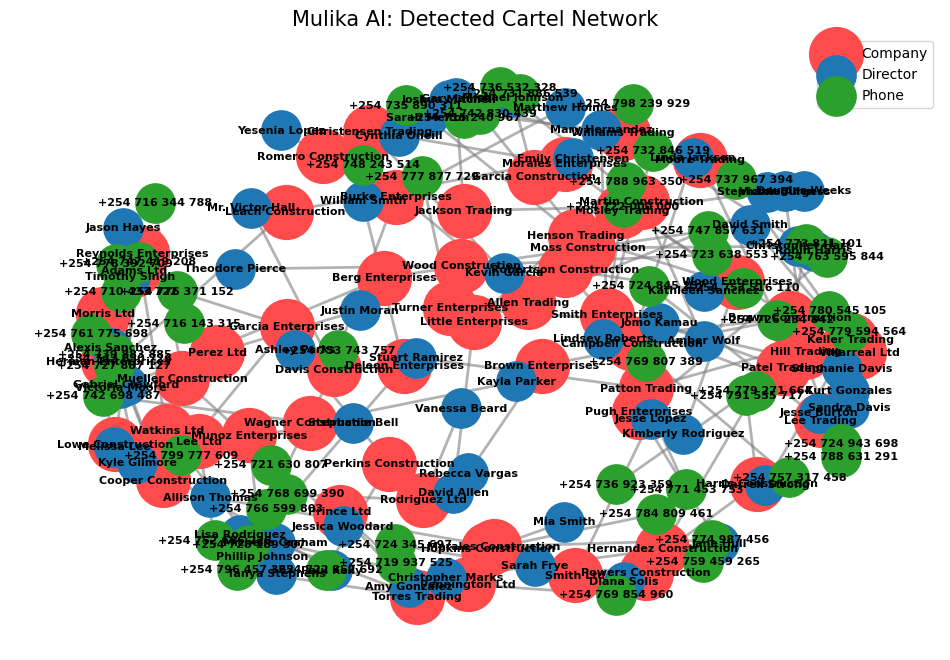

✅ SUCCESS: The spiderweb shows how the companies are secretly connected.


In [9]:
# --- MILESTONE 3: VISUALIZING THE CARTEL (GRAPH ANALYTICS) ---
import networkx as nx
import matplotlib.pyplot as plt

print("🕸️ Building Cartel Network Graph...")

# 1. Initialize the Graph
G = nx.Graph()

# 2. Add Nodes and Edges from our Suspicious Data
# We only map the "High Risk" items to keep the chart clean
suspicious_rows = df[df['Fraud_Type'] != "None"]

for index, row in suspicious_rows.iterrows():
    company = row['Company']
    director = row['Director']
    phone = row['Phone']

    # Add Nodes (The Entities)
    G.add_node(company, type='Company', color='red')
    G.add_node(director, type='Director', color='blue')
    G.add_node(phone, type='Phone', color='green')

    # Add Edges (The Connections)
    G.add_edge(company, director, label='Managed By')
    G.add_edge(company, phone, label='Contact Info')

# 3. DRAW THE NETWORK
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5) # k regulates the distance between nodes

# Draw Nodes by Type
companies = [n for n, attr in G.nodes(data=True) if attr['type'] == 'Company']
directors = [n for n, attr in G.nodes(data=True) if attr['type'] == 'Director']
phones = [n for n, attr in G.nodes(data=True) if attr['type'] == 'Phone']

nx.draw_networkx_nodes(G, pos, nodelist=companies, node_color='#ff4b4b', node_size=1500, label="Company")
nx.draw_networkx_nodes(G, pos, nodelist=directors, node_color='#1f77b4', node_size=800, label="Director")
nx.draw_networkx_nodes(G, pos, nodelist=phones, node_color='#2ca02c', node_size=800, label="Phone")

# Draw Edges and Labels
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Mulika AI: Detected Cartel Network", fontsize=15)
plt.legend(scatterpoints=1)
plt.axis('off')
plt.show()

print("✅ SUCCESS: The spiderweb shows how the companies are secretly connected.")